In [1]:
# import pandas as pd
# pd.read_csv('../working-vars/Y_gmm_20250717.csv', index_col=0)

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from importlib import reload

import mod_loading as loader
import figs_pcm 
import datetime 

In [ ]:
# Import data as of Jan 19 2026
reload(loader)
# [coreDS, coreINDEX, bgcDS, bgcINDEX, socat] = loader.import_data(type=['core', 'bgc', 'socat'])


# [coreDS, coreINDEX] = loader.import_core_data(type = 'L3_only')
[bgcDS, bgcINDEX] = loader.import_bgc_data(type = 'L3_only')


#  socat colocation data
sepstat_7d = loader.import_socat_colocation()
socat_df = sepstat_7d[sepstat_7d['latitude']<-35]


In [4]:
reload(loader) # output of 1.1
[Y_gmm, allprobs, pcm_params, coreDF] = loader.import_clustering_results(pcm_params='pc8_gmm7') #Y_gmm # used to be gmm_desc instead of pcm_params

In [3]:
pcm_params='pc8_gmm7'
n_gmm=7

# SOCAT Classification

In [31]:
# ========= import socat data
reload(loader)
sepstat_7d = loader.import_socat_colocation()
socat_df = sepstat_7d[sepstat_7d['latitude']<-35]

In [21]:
# socat_df = socat.to_dataframe()
socat_df

,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,pco2water_sst_wet,...,xco2water_sst_dry,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep
0,-24.64215,-73.725900,341.6865,34.074,-1.2305,1.483947,NaN,341.700,NaN,343.200,...,NaN,2014-01-02 11:36:53,06AQ20131221_id0,-2062.0,7900378_id041,2014-01-09,-71.616580,-22.823985,6.720278,242.124951
1,-36.40135,-77.100350,365.8905,34.281,-1.7040,9.499502,NaN,365.900,NaN,367.500,...,NaN,2014-01-10 11:59:17,06AQ20131221_id0,-1087.0,7900378_id041,2014-01-09,-71.616580,-22.823985,1.295278,729.272575
2,-38.14620,-77.899100,275.3920,34.279,-1.4480,15.491701,NaN,275.400,NaN,276.600,...,NaN,2014-01-16 11:48:03,06AQ20131221_id0,-1168.0,7900378_id042,2014-01-19,-71.682778,-23.213771,2.700012,811.679788
3,-38.94590,-77.608000,375.1900,34.418,-1.7700,16.295197,NaN,375.200,NaN,376.900,...,NaN,2014-01-17 07:05:05,06AQ20131221_id0,-1009.0,7900378_id042,2014-01-19,-71.682778,-23.213771,1.896516,799.773551
4,-28.47890,-74.557400,298.7880,33.760,-1.3940,21.498843,NaN,298.800,NaN,300.100,...,NaN,2014-01-22 11:58:20,06AQ20131221_id1,-1639.0,7900378_id043,2014-01-29,-71.743994,-23.090656,6.695984,357.493891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6283,163.00795,-39.536095,370.5850,35.444,15.0160,3497.534375,372.560,370.135,NaN,371.470,...,377.375,2023-07-30 12:49:30,PAT520230724_id1,-3646.0,5905508_id071,2023-08-01,-39.699600,163.253800,2.079502,27.820801
6284,154.23600,-37.704690,364.7370,35.543,16.0950,3498.604861,366.830,364.440,NaN,365.740,...,370.690,2023-07-31 14:31:00,PAT520230724_id1,-4523.0,5906152_id108,2023-07-30,-37.819290,152.754590,1.312465,130.846019
6285,149.00550,-38.579580,366.4580,35.644,15.7330,3499.499306,368.570,366.130,NaN,367.450,...,367.770,2023-08-01 11:59:00,PAT520230724_id1,-2813.0,5905515_id120,2023-07-28,-38.527290,150.643725,3.723206,142.572572
6286,177.57530,-37.193580,350.2155,35.146,15.6535,3574.664236,352.555,349.850,NaN,351.125,...,354.565,2023-10-15 15:56:30,PAT520231011_id1,-1709.0,5906421_id087,2023-10-15,-37.191630,178.572070,0.086331,88.292512


In [5]:
# === Separate socat data by class

# socat_df = sepstat_7d[sepstat_7d['latitude']<-35].reset_index()
for ind in range(len(socat_df)):
    try:
        socat_df.loc[ind,  'class'] = int(Y_gmm.loc[socat_df.loc[ind, 'nearest_profid'], 'class'])
    except:
        socat_df.loc[ind,  'class'] = None

# Account for missing classes by looking at neighboring observations in the same cruise
# If same, then fill in the missing class
missingClasses = socat_df[socat_df['class'].isna()] #.reset_index()
Replaced = []
notReplaced = []
for ind, row in missingClasses.iterrows():
    obs_ID = row.expoID
    cruise_num = str(obs_ID).split('_')[0]
    obs_num = int(str(obs_ID).split('id')[1])
    try:
        class_before = socat_df[socat_df['expoID'] == (cruise_num + '_id' + str(obs_num -1))]['class'].values[0]
        class_after  = socat_df[socat_df['expoID'] == (cruise_num + '_id' + str(obs_num +1))]['class'].values[0]
        if class_before == class_after:
            socat_df.loc[socat_df['expoID'] == obs_ID, 'class'] = class_before
            Replaced.append(obs_ID)
    except:
        notReplaced.append(obs_ID)


# Make dictionary
socat_classes = {k:None for k in range(n_gmm)}
for ind in range(n_gmm):
    socat_classes[ind] = socat_df[socat_df['class']==ind]

In [33]:
socat_df[~socat_df['class'].isna()]

,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,pco2water_sst_wet,...,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class
0,-24.64215,-73.725900,341.6865,34.074,-1.2305,1.483947,NaN,341.700,NaN,343.200,...,2014-01-02 11:36:53,06AQ20131221_id0,-2062.0,7900378_id041,2014-01-09,-71.616580,-22.823985,6.720278,242.124951,3.0
1,-36.40135,-77.100350,365.8905,34.281,-1.7040,9.499502,NaN,365.900,NaN,367.500,...,2014-01-10 11:59:17,06AQ20131221_id0,-1087.0,7900378_id041,2014-01-09,-71.616580,-22.823985,1.295278,729.272575,3.0
2,-38.14620,-77.899100,275.3920,34.279,-1.4480,15.491701,NaN,275.400,NaN,276.600,...,2014-01-16 11:48:03,06AQ20131221_id0,-1168.0,7900378_id042,2014-01-19,-71.682778,-23.213771,2.700012,811.679788,3.0
3,-38.94590,-77.608000,375.1900,34.418,-1.7700,16.295197,NaN,375.200,NaN,376.900,...,2014-01-17 07:05:05,06AQ20131221_id0,-1009.0,7900378_id042,2014-01-19,-71.682778,-23.213771,1.896516,799.773551,3.0
4,-28.47890,-74.557400,298.7880,33.760,-1.3940,21.498843,NaN,298.800,NaN,300.100,...,2014-01-22 11:58:20,06AQ20131221_id1,-1639.0,7900378_id043,2014-01-29,-71.743994,-23.090656,6.695984,357.493891,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6283,163.00795,-39.536095,370.5850,35.444,15.0160,3497.534375,372.560,370.135,NaN,371.470,...,2023-07-30 12:49:30,PAT520230724_id1,-3646.0,5905508_id071,2023-08-01,-39.699600,163.253800,2.079502,27.820801,4.0
6284,154.23600,-37.704690,364.7370,35.543,16.0950,3498.604861,366.830,364.440,NaN,365.740,...,2023-07-31 14:31:00,PAT520230724_id1,-4523.0,5906152_id108,2023-07-30,-37.819290,152.754590,1.312465,130.846019,4.0
6285,149.00550,-38.579580,366.4580,35.644,15.7330,3499.499306,368.570,366.130,NaN,367.450,...,2023-08-01 11:59:00,PAT520230724_id1,-2813.0,5905515_id120,2023-07-28,-38.527290,150.643725,3.723206,142.572572,4.0
6286,177.57530,-37.193580,350.2155,35.146,15.6535,3574.664236,352.555,349.850,NaN,351.125,...,2023-10-15 15:56:30,PAT520231011_id1,-1709.0,5906421_id087,2023-10-15,-37.191630,178.572070,0.086331,88.292512,6.0


In [6]:
# Updated Jan 2026
list = []
for class_id, ds in socat_classes.items():
    # Create a new coordinate 'class' for each profile
    temp_ds = (xr.Dataset.from_dataframe(socat_classes[class_id]))
    list.append(temp_ds.assign_coords(cluster = temp_ds['class'].astype(int)+1))

# Merge all classes along profid
clustered_socat_ds = xr.concat(list, dim="index")


clustered_socat_ds = clustered_socat_ds.rename_vars({'yearday':'linear_time'})

for x in ['latitude', 'longitude', 'datetime', 'linear_time']:
    clustered_socat_ds = clustered_socat_ds.set_coords(x) 
clustered_socat_ds = clustered_socat_ds.assign_attrs({'gmm_run_params': pcm_params,
                        'pcm_run_date': datetime.datetime.now().strftime('%Y%m%d'),
                        'dbar_limit' : '0-500dbar'
                        })
clustered_socat_ds

<xarray.Dataset>
Dimensions:            (index: 6087)
Coordinates:
  * index              (index) int64 46 58 83 85 86 ... 6279 6281 6282 6286 6287
    longitude          (index) float64 140.3 144.1 135.0 ... 172.8 177.6 171.8
    latitude           (index) float64 -48.28 -47.84 -47.32 ... -37.19 -38.04
    linear_time        (index) float64 30.48 68.51 106.5 ... 3.575e+03 3.585e+03
    datetime           (index) object '2014-01-31 11:31:33' ... '2023-10-25 1...
    cluster            (index) int64 1 1 1 1 1 1 1 1 1 1 ... 7 7 7 7 7 7 7 7 7 7
Data variables: (12/19)
    fco2rec            (index) float64 345.1 361.2 361.3 ... 364.9 350.2 355.7
    sal                (index) float64 34.53 34.12 34.45 ... 35.31 35.15 35.35
    sst                (index) float64 11.46 11.29 11.15 ... 16.78 15.65 15.57
    fco2water_equ_wet  (index) float64 nan nan nan nan ... 366.2 352.6 358.0
    fco2water_sst_wet  (index) float64 nan nan nan nan ... 364.0 349.9 355.1
    pco2water_equ_wet  (index) float64 nan nan nan nan nan ... nan nan nan nan
    ...                 ...
    prof_datetime      (index) object '2014-02-06' '2014-03-12' ... '2023-10-23'
    prof_lat           (index) float64 -48.35 -47.26 -46.4 ... -37.19 -36.1
    prof_lon           (index) float64 144.2 143.9 131.6 ... 167.9 178.6 169.4
    yd_sep             (index) float64 6.07 1.927 4.344 ... 0.8951 0.08633 1.878
    km_sep             (index) float64 284.4 65.43 273.6 ... 452.2 88.29 302.9
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 6.0 6.0 6.0 6.0
Attributes:
    gmm_run_params:  pc8_gmm7
    pcm_run_date:    20260204
    dbar_limit:      0-500dbar

In [7]:
# ===== Optional save SOCAT clustered

save = True
datetag = datetime.datetime.now().strftime('%Y%m%d')
if save:
    clustered_socat_ds.to_netcdf('../working-vars/pcm/' + pcm_params + '/clustered_socat_1d_acc' + datetag + '.nc')
    print('Saved clustered SOCAT to ' + '../working-vars/pcm/' + pcm_params + '/clustered_socat_1d_acc' + datetag + '.nc; ' + datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Saved clustered SOCAT to ../working-vars/pcm/pc8_gmm7/clustered_socat_1d_acc20260204.nc; 2026-02-04 11:07:10


In [8]:
for ind in range(n_gmm):
    print(f'Class {ind+1}: {len(socat_classes[ind].index.values)}')

Class 1: 1653
Class 2: 847
Class 3: 341
Class 4: 1194
Class 5: 194
Class 6: 519
Class 7: 1339


<GeoAxes: >

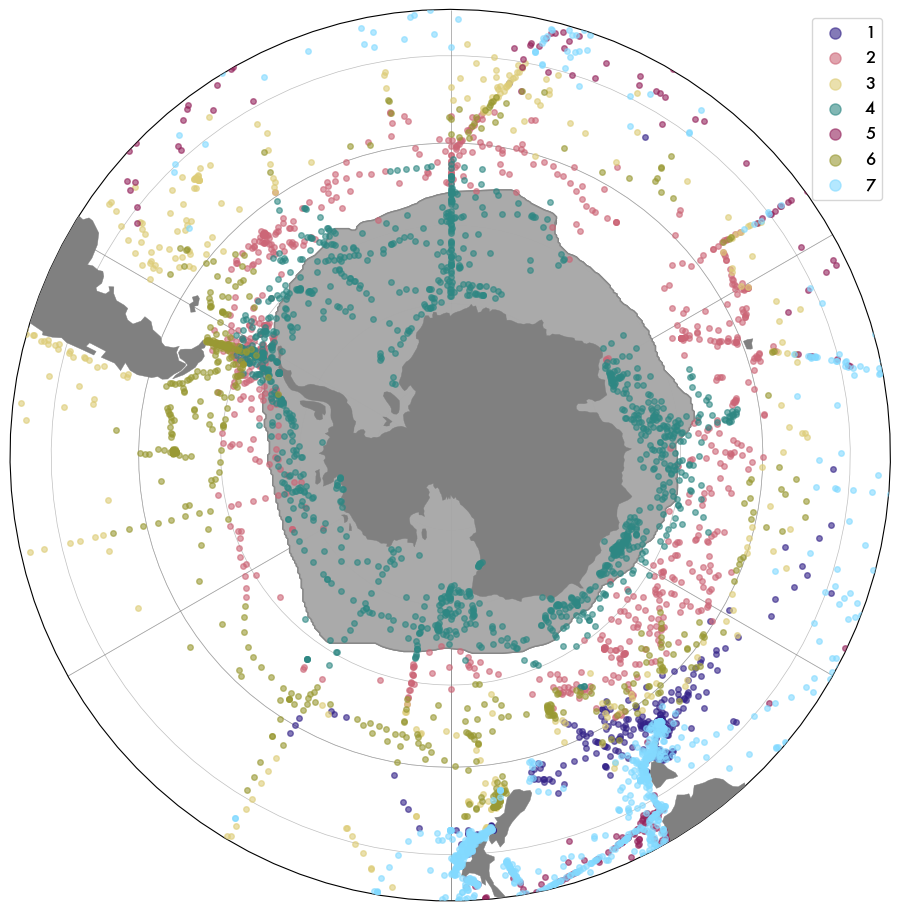

In [72]:
reload(figs_pcm)

# To plot all classes on one plot
figs_pcm.sopolar_classes(socat_classes, figsize=(9,9), dotsize=16, markerscale=2, dotalpha=0.6)

# Classify bgcArgo data and create new xr Dataset



In [10]:
[bgcDS, bgcINDEX] = loader.import_bgc_data(type = 'L3_only')
# bgcINDEX.sel(profid=bgcDS.profid.values)

In [ ]:
# [bgcDS_test, bgcINDEX_test] = loader.import_bgc_data(type = 'test')

In [ ]:
# === Separate bgc data by class
n_gmm = int(pcm_params.split('_')[1][-1])
bgc_df = bgcINDEX.to_dataframe()

for ind in bgc_df.index:
    try:
        bgc_df.loc[ind,  'class'] = int(Y_gmm.loc[ind, 'class'])
    except:
        bgc_df.loc[ind,  'class'] = None

# Make dictionary
bgc_classes = {k:None for k in range(n_gmm)}
for ind in range(n_gmm):
    # bgc_classes[ind] = bgc_df[bgc_df['class']==ind]
    bgc_classes[ind] = bgcDS.sel({'profid':[x for x in bgc_df[bgc_df['class']==ind].index]})


# Create new xarray object
list = []
for class_id, ds in bgc_classes.items():
    # Create a new coordinate 'class' for each profile
    ds_with_class = ds.assign_coords(cluster = (ds.latitude * 0 + class_id + 1))
    list.append(ds_with_class)

# Merge all classes along profid
merged_ds = xr.concat(list, dim="profid")
merged_ds = merged_ds.rename_vars({'yearday':'linear_time'})
merged_ds = merged_ds.assign_attrs({'gmm_run_params': pcm_params,
                        'pcm_run_date': datetag,
                        'dbar_limit' : '0-500dbar'
                        })

merged_ds

In [ ]:
# list = []
# for class_id, ds in bgc_classes.items():
#     # Create a new coordinate 'class' for each profile
#     ds_with_class = ds.assign_coords(cluster = (ds.latitude * 0 + class_id + 1))
#     list.append(ds_with_class)

# # Merge all classes along profid
# merged_ds = xr.concat(list, dim="profid")

# merged_ds.assign_attrs({'gmm_run_params': gmm_desc})

ValueError: conflicting sizes for dimension 'pressure': length 1 on 'yearday' and length 197 on {'profid': 'profid', 'pressure': 'pressure'}

In [16]:
# Save new Dataset with cluster assignments
save=True
if save:
    datetag = datetime.datetime.now().strftime('%Y%m%d')
    merged_ds.to_netcdf('../working-vars/pcm/'+ pcm_params +'/clustered_bgcArgo_acc' + datetag + '.nc')
    print('Saved to ' + '../working-vars/pcm/'+ pcm_params +'/clustered_bgcArgo_acc' + datetag + '.nc; ' + datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Saved to ../working-vars/pcm/pc8_gmm7/clustered_bgcArgo_acc20260204.nc; 2026-02-04 11:10:11


## Plots of bgc Argo data

In [18]:
# Compare number of training obs for each class
nobs_table = pd.DataFrame(index = range(n_gmm))
for ind in range(n_gmm):
    nobs_table.loc[ind, 'socat'] = int(len(socat_classes[ind].index.values))
    nobs_table.loc[ind, 'bgc'] = int(len(bgc_classes[ind].profid.values))
    
nobs_table['total_obs'] = nobs_table['socat'] + nobs_table['bgc']
nobs_table.index=range(1,n_gmm+1)
nobs_table

,socat,bgc,total_obs
1,1653.0,901.0,2554.0
2,847.0,2473.0,3320.0
3,341.0,1615.0,1956.0
4,1194.0,2822.0,4016.0
5,194.0,361.0,555.0
6,519.0,2163.0,2682.0
7,1339.0,1044.0,2383.0


In [19]:
from matplotlib import pyplot as plt

<GeoAxes: title={'center': 'Class 6'}>

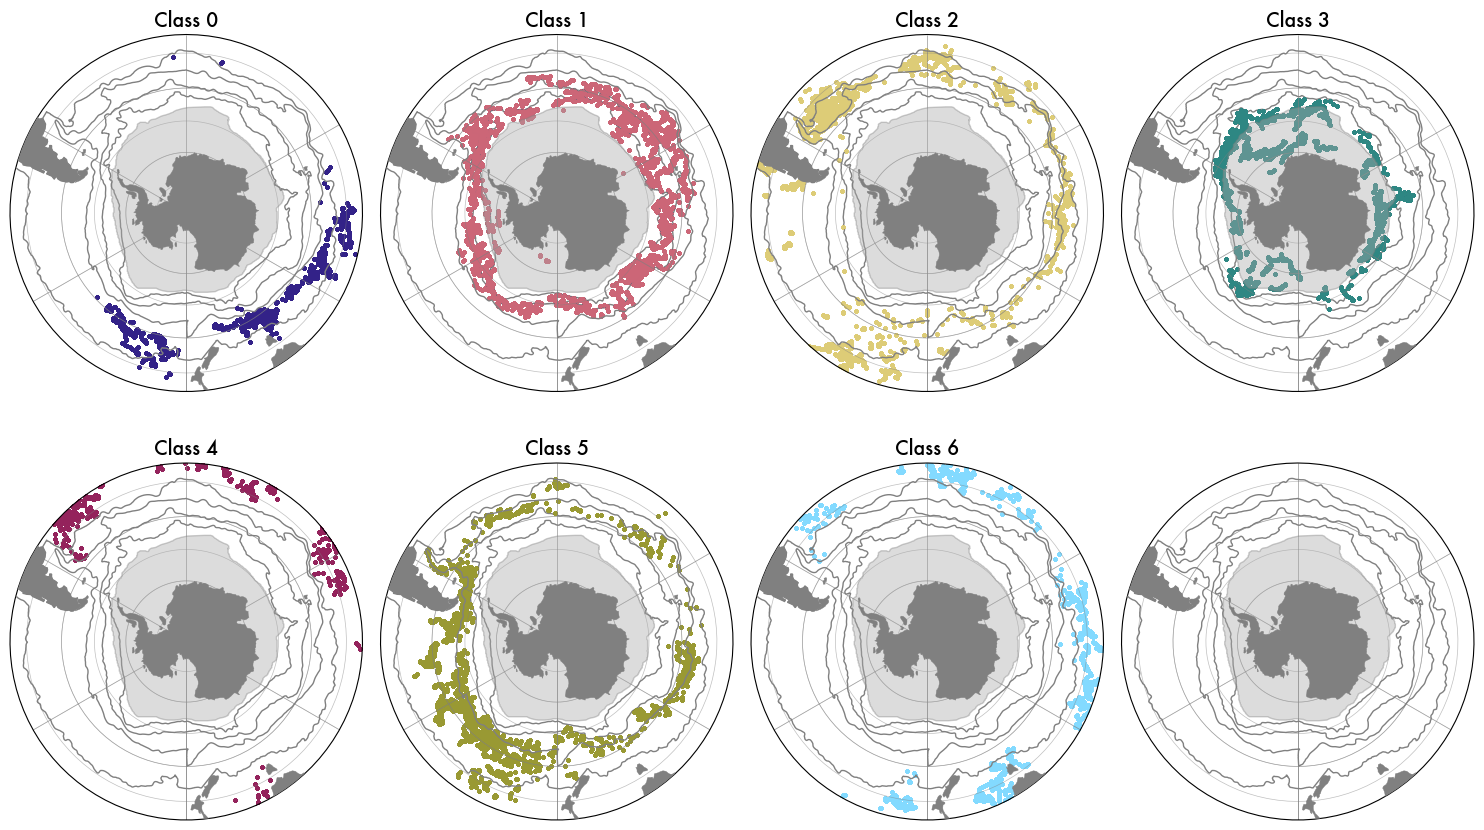

In [21]:
reload(figs_pcm)
figs_pcm.sopolar_classes_paneled(bgc_classes, numpanels=[2,4], figsize=(9,9))

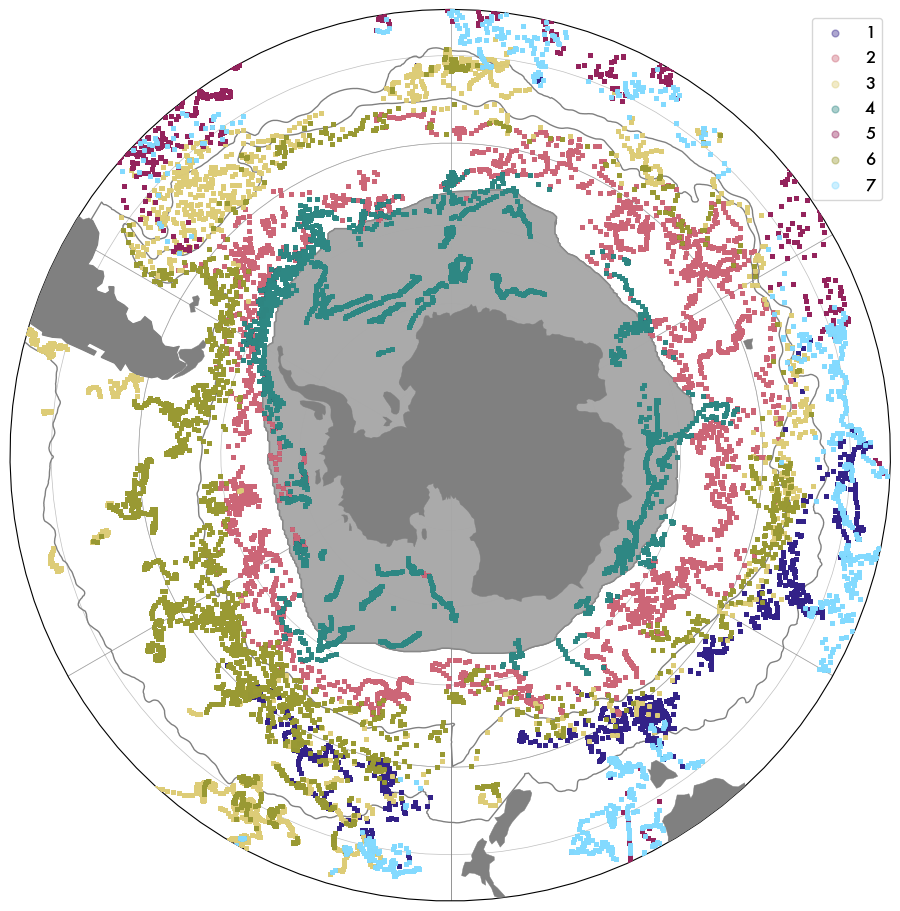

In [69]:
reload(figs_pcm)

# To plot all classes on one plot
# ax = figs_pcm.sopolar_classes(bgc_classes, 
#                          figsize=(9,9), 
#                          dotsize=6, markerscale=2)

# figs_pcm.sopolar_classes(socat_classes, inds=range(8), 
#                          ax=ax, figsize=(9,9), 
#                          dotsize=6, markerscale=2, legend=False)

# ax.set_title('BGC and SOCAT data')

import mod_southpolarplot as sopo

ax = figs_pcm.sopolar_classes(bgc_classes, 
                         figsize=(9,9), 
                         dotsize=6, markerscale=2)

sopo.add_frontlines(ax, types=['saf', 'stf'])

In [59]:
# Compare number of training obs for each class
nobs_table = pd.DataFrame(index = range(n_gmm))
for ind in range(n_gmm):
    nobs_table.loc[ind, 'socat'] = int(len(socat_classes[ind].index.values))
    nobs_table.loc[ind, 'bgc'] = int(len(bgc_classes[ind].profid.values))
    
nobs_table['total_training'] = nobs_table['socat'] + nobs_table['bgc']
nobs_table.index=range(1, 1+n_gmm)
nobs_table

,socat,bgc,total_training
1,1653.0,901.0,2554.0
2,847.0,2470.0,3317.0
3,341.0,1606.0,1947.0
4,1194.0,2819.0,4013.0
5,194.0,361.0,555.0
6,519.0,2145.0,2664.0
7,1339.0,1044.0,2383.0


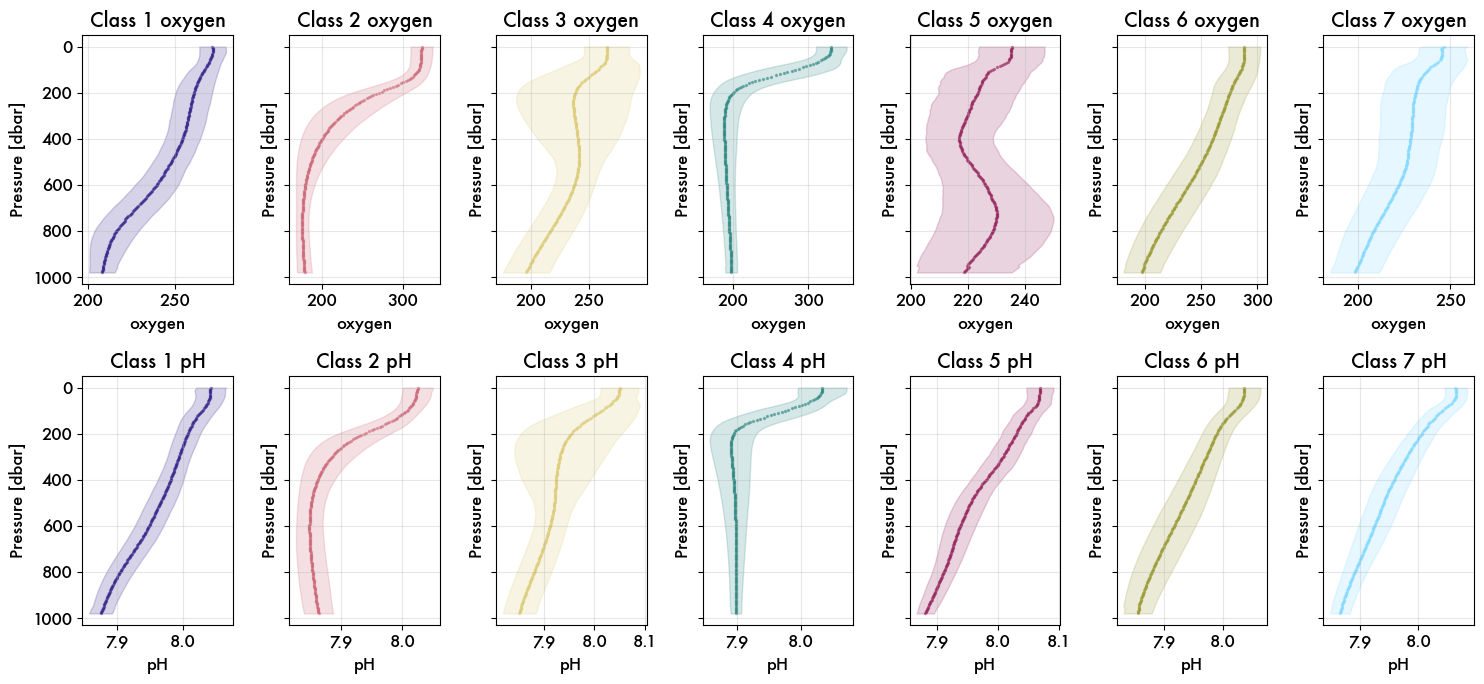

In [64]:
reload(figs_pcm)
figs_pcm.mean_tracer_profiles_paneled(bgc_classes, vars = ['oxygen', 'pH'],
                                 figsize = (15,7), numpanels=[2,7])